# Basic Task 1

L96を４次のRunge-Kutta法を用いて実装する。パラメータ値Fを色々と変え、F=8の時にカオスとなることを確認する。ここでは、Runge-Kuttaはライブラリを用いずに自分でコーディングする事。また、オイラー法など、他の積分スキームと比較してみる。

ヒント) まずは、原著論文 Lorenz and Emanuel (1998)のFig. 1を再現する。


## Lorenz96モデルとは？ 🌪️
カオス的な振る舞いを示す、単純化された大気モデルです。気象学者のエドワード・ローレンツが1996年に提唱しました。

このモデルは、ある緯度上に等間隔に並んだ地点の気象変数が、次の瞬間にどう変化するか（=変化の仕方）を微分方程式で定義します。

Lorenz96モデルの微分方程式は以下のように表されます：
$$
\frac{dx_i}{dt} = (x_{i+1} - x_{i-2})x_{i-1} - x_i + F
$$
ここで、$x_i$は地点$i$の気象変数（例えば気温や風速）を表し、$F$は外部からの強制力（例えば太陽放射など）を表します。インデックスは周期的に扱われ、つまり$x_{N+1} = x_1$、$x_0 = x_N$となります。
このモデルは、シンプルながらもカオス的な振る舞いを示し、気象予測の不確実性やカオス理論の理解に役立ちます。特に、初期条件に対する敏感な依存性（バタフライ効果）を示すため、気象予測の限界を理解する上で重要な役割を果たしています。
この数式だけでは未来の値を直接求めることはできないため、コンピュータを使って未来の状態を少しずつ計算していく「数値解法」が必要になります。

## 時間積分メソッド ⏳
数値解法にはいくつかの方法がありますが、ここでは代表的な2つを紹介します。

### 1. オイラー法 (Euler Method)
最もシンプルで直感的な数値解法です。

コンセプト:
「現在の場所の傾き（変化の仕方）を見て、その方向にまっすぐ少しだけ進む」という考え方を何度も繰り返すことで、未来の状態を近似します。

オイラー法の計算式:
$$
x_{n+1} = x_n + h \cdot f(x_n, t_n)
$$
ここで、$x_n$は現在の状態、$h$は時間ステップの大きさ、$f(x_n, t_n)$は現在の状態における変化の仕方（微分方程式で定義される）を表します。

### 2. ルンゲクッタ法 (Runge-Kutta Method) 🎯
オイラー法を大幅に改良した、精度の高い数値解法です。特に**4次のルンゲクッタ法（RK4）**が非常によく使われます。

コンセプト:
オイラー法が「出発点の傾き」だけを見ていたのに対し、ルンゲクッタ法はより賢い方法を取ります。

出発点だけでなく、「少し進んだ中間地点での傾き」などを複数回計算し、それらを絶妙なバランスで重み付け平均することで、より正確な「全体の傾き」を推定します。これにより、本来の軌道に非常に近いステップで進むことができます。

ルンゲクッタ法の計算式（4次の場合）:
$$
\begin{align*}
k_1 & = h \cdot f(x_n, t_n) \\
k_2 & = h \cdot f\left(x_n + \frac{k_1}{2}, t_n + \frac{h}{2}\right) \\
k_3 & = h \cdot f\left(x_n + \frac{k_2}{2}, t_n + \frac{h}{2}\right) \\
k_4 & = h \cdot f(x_n + k_3, t_n + h) \\
x_{n+1} & = x_n + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)
\end{align*}
$$
ここで、$k_1, k_2, k_3, k_4$はそれぞれ異なる地点での傾きを表し、これらを組み合わせて次の状態$x_{n+1}$を計算します。

ルンゲクッタ法の計算式（2次の場合）:
$$
\begin{align*}
k_1 & = h \cdot f(x_n, t_n) \\
k_2 & = h \cdot f\left(x_n + \frac{k_
1}{2}, t_n + \frac{h}{2}\right) \\
x_{n+1} & = x_n + k_2
\end{align*}
$$
ここで、$k_1, k_2$はそれぞれ異なる地点での傾きを表し、これらを組み合わせて次の状態$x_{n+1}$を計算します。

## Pythonでの実装例

In [1]:
# 各種メソッドの定義
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Lorenz96モデルの定義
def L96(x, F):
    """
    Lorenz96モデルの微分方程式を定義する関数
    x: 状態変数の配列
    F: 外部からの強制力
    """
    N = len(x)
    dxdt = np.zeros(N)
    for i in range(N):
        dxdt[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F
    return dxdt
## オイラー法の実装
def euler_step(x, F, dt):
    """
    オイラー法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    dxdt = L96(x, F)
    return x + dxdt * dt
## 4次のルンゲクッタ法の実装
def rk4_step(x, F, dt):
    """
    4次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F)
    k2 = L96(x + 0.5 * dt * k1, F)
    k3 = L96(x + 0.5 * dt * k2, F)
    k4 = L96(x + dt * k3, F)
    return x + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

## 2次のルンゲクッタ法の実装
def rk2_step(x, F, dt):
    """
    2次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F)
    k2 = L96(x + dt * k1, F)
    return x + (dt / 2) * (k1 + k2)

## 状態変数の配列のコンストラクタ
class StateArray:
    def __init__(self, N, F, dt, method='rk4'):
        """
        状態変数の配列を初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        method: 使用する時間積分メソッド ('euler', 'rk2', 'rk4')
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.method = method
        self.x = F * np.ones(N)  # 初期状態をFで初期化
        self.x[N // 2-1] *= 1.001  # 中央の値を少し変化させる

    def step(self):
        """
        1ステップの時間積分を実行するメソッド
        """
        if self.method == 'euler':
            self.x = euler_step(self.x, self.F, self.dt)
        elif self.method == 'rk2':
            self.x = rk2_step(self.x, self.F, self.dt)
        elif self.method == 'rk4':
            self.x = rk4_step(self.x, self.F, self.dt)
        else:
            raise ValueError("Unknown method: {}".format(self.method))

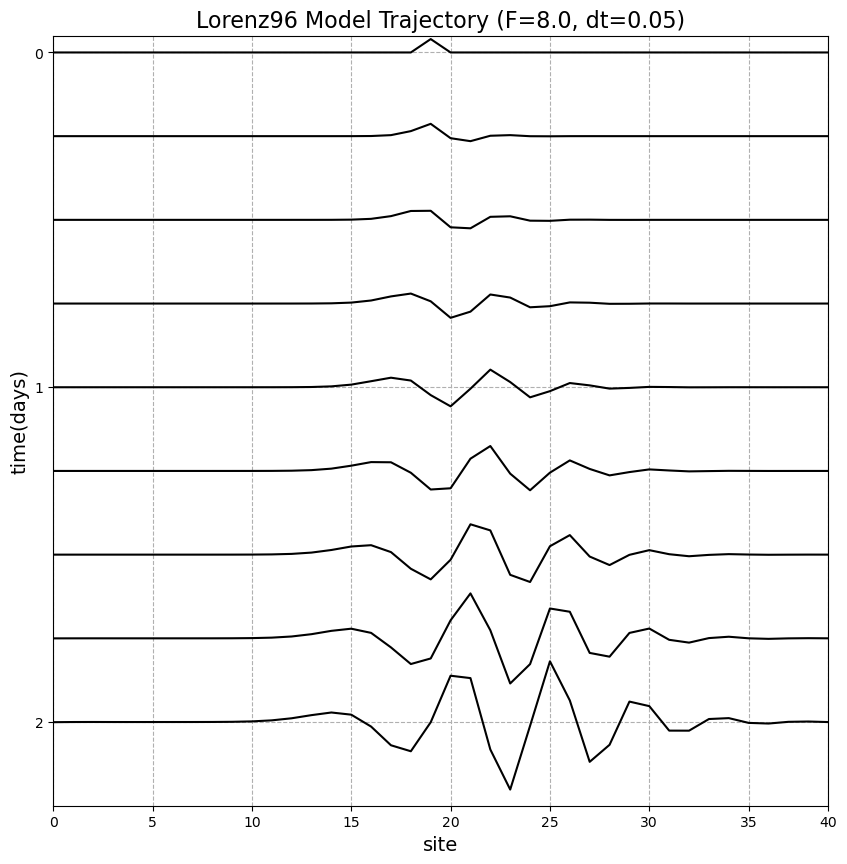

In [2]:
# L96を4次のRunge-Kutta法を用いて実装
# パラメータ値Fを色々と変え、F=8の時にカオスとなることを確認する
N = 40  # 状態変数の数
dt = 0.050  # 時間間隔
F = 8.0  # 外部からの強制力
steps = 9 # シミュレーションのステップ数
state = StateArray(N, F, dt, method='rk4')
trajectory = np.zeros((steps, N))  # 軌道を保存する配列
for i in range(steps):
    trajectory[i] = state.x
    state.step()
# 結果のプロット
plt.figure(figsize=(10, 10))
for i in range(steps):
    plt.plot((trajectory[i]-8-i*0.05)*10, label='x{}'.format(i), color='black')
plt.xlabel('site', fontsize=14)
plt.ylabel('time(days)', fontsize=14)
plt.xlim(0, N-1)
plt.ylim(-4.5, 0.1)
plt.xticks([0,5,10,15,20,25,30,35,39], labels=['0','5','10','15','20','25','30','35','40'])
plt.yticks(np.arange(0, -4.1, -2), labels=['0', '1', '2'])

plt.grid(linestyle='--')
plt.title('Lorenz96 Model Trajectory (F={}, dt={})'.format(F, dt), fontsize=16)
plt.show()

### 外力パラメータFの値ごとの挙動の違い
外力Fが比較的小さい値（例えば F < 4 の大部分の領域）では、システムは安定した振る舞いを見せます。

定常状態: Fが非常に小さいと、全ての変数（x 
i
​
 ）はやがて時間変化しない一定の値に収束します。

周期的振動: Fを少しずつ大きくしていくと、システムは一定のパターンを繰り返す周期的な振動を始めます。これは、モデル内の波が一定の速度と形で伝播していくような状態です。この段階では、未来の状態は完全に予測可能です。

簡単に言えば、この領域でのシステムは規則正しく、安定した「波」のような動きをします。

#### Fが4より小さい場合：周期的で予測可能な振る舞い 🌊
外力Fが比較的小さい値（例えば F < 4 の大部分の領域）では、システムは安定した振る舞いを見せます。

定常状態: Fが非常に小さいと、全ての変数（x 
i
​
 ）はやがて時間変化しない一定の値に収束します。

周期的振動: Fを少しずつ大きくしていくと、システムは一定のパターンを繰り返す周期的な振動を始めます。これは、モデル内の波が一定の速度と形で伝播していくような状態です。この段階では、未来の状態は完全に予測可能です。

簡単に言えば、この領域でのシステムは規則正しく、安定した「波」のような動きをします。

#### Fが4より大きい場合：カオス的で予測不可能な振る-舞い 🌪️
Fがある閾値を超えて大きくなると、システムの振る舞いは劇的に変化し、カオスと呼ばれる状態に突入します。研究では、この変化が**Fがおおよそ3.8近辺**から顕著になり始めると示唆されています。したがって、Fが4より大きい領域は、多くの場合カオス的な振る舞いを示す領域です。

不規則な変動: システムの状態はもはや単純な周期に従わず、極めて不規則で複雑に変動します。

初期値鋭敏性（バタフライ効果）: 計算を始めるときの初期値がほんのわずかでも違うと、時間が経つにつれてその差が指数関数的に増大し、全く異なる未来の状態に至ります。これにより、長期的な予測が事実上不可能になります。

有名なカオス領域: データ同化などの研究で最もよく使われるF=8という設定は、このカオスが十分に発達した領域にあります。



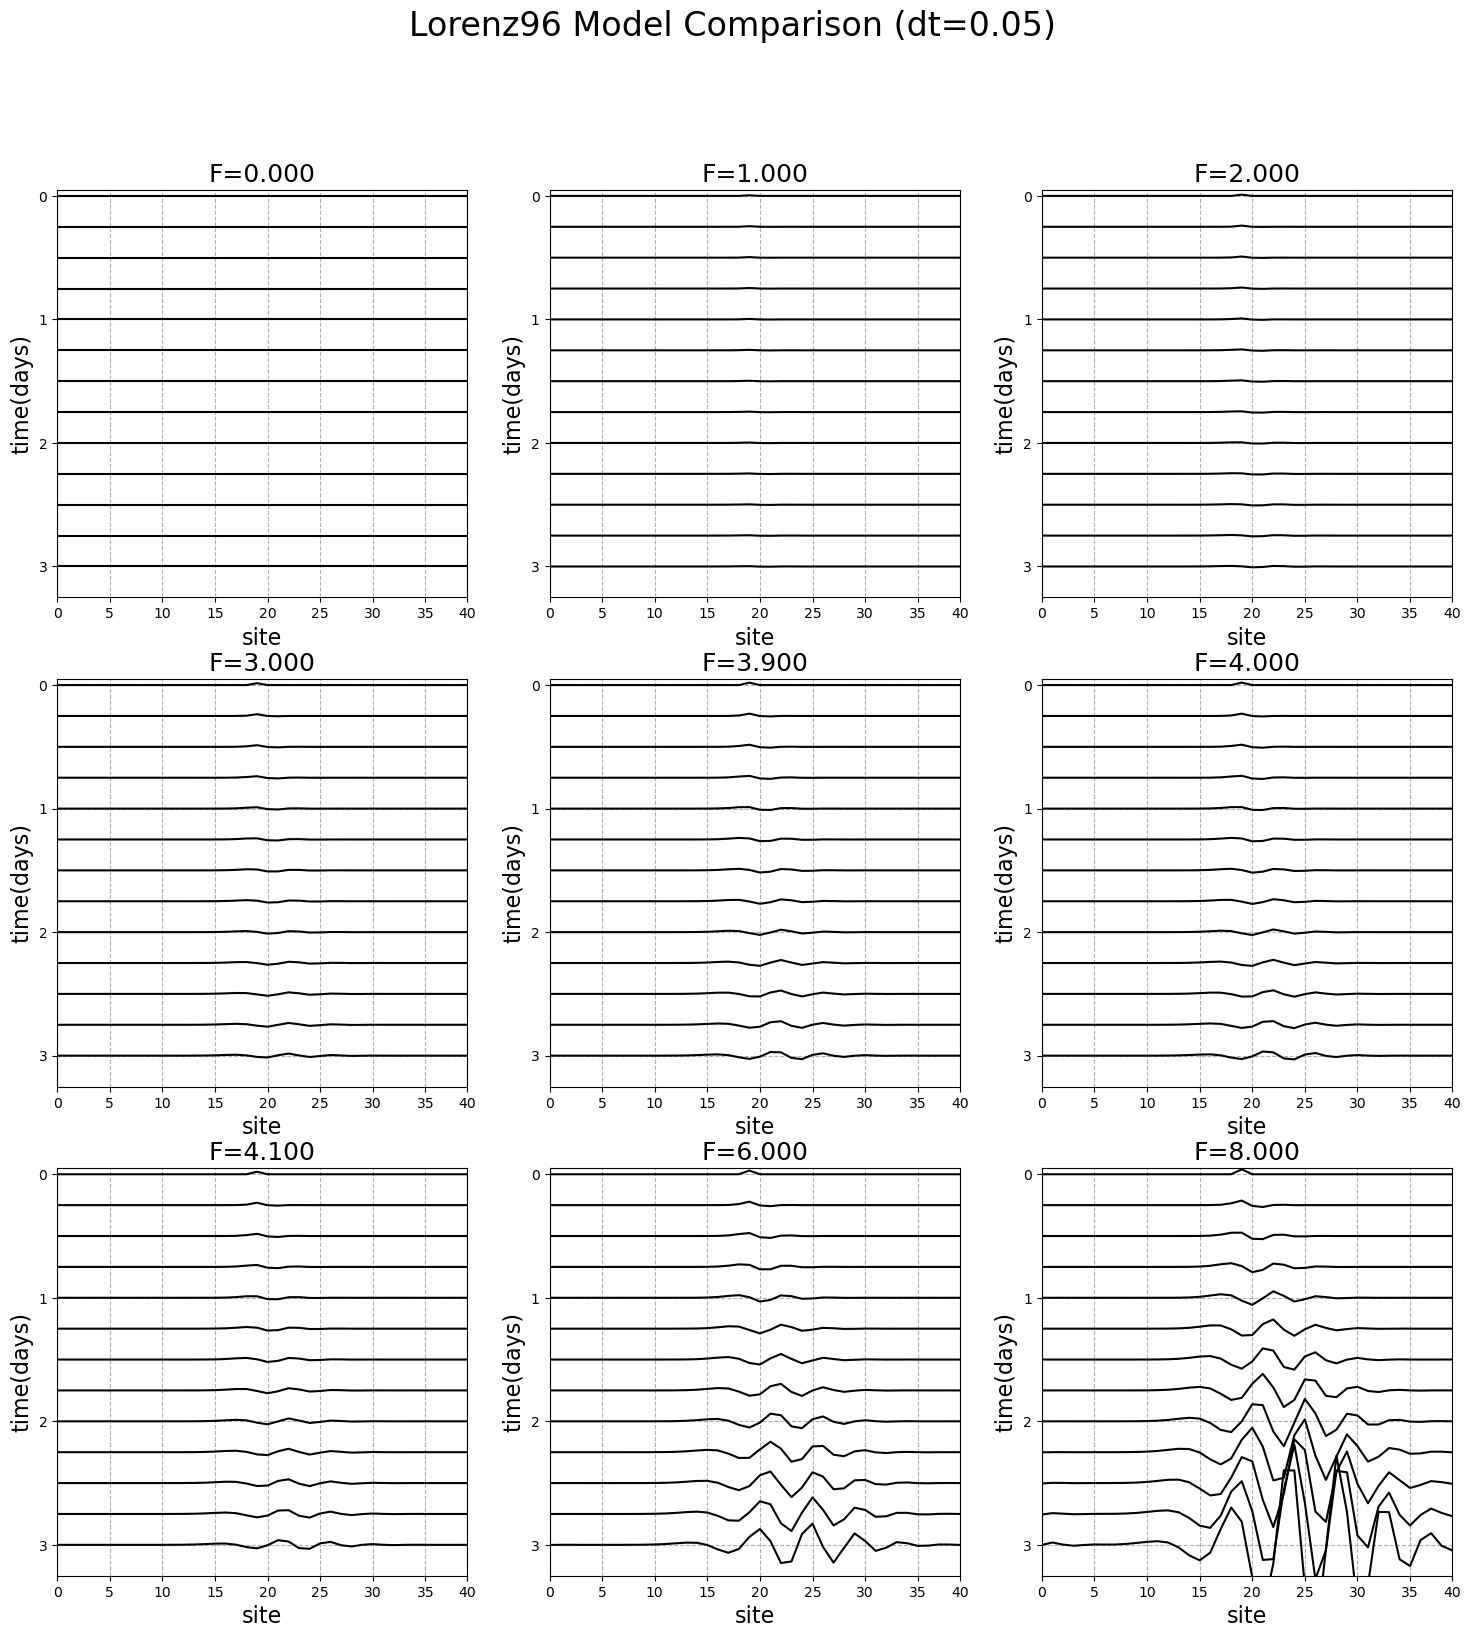

In [6]:
# F=0,1,2,4,6,8の場合で一斉描画して比較
N = 40  # 状態変数の数
dt = 0.050  # 時間間隔
F_values = [0, 1, 2, 3, 3.9, 4, 4.1, 6, 8]  # 比較するF値
steps = 13  # シミュレーションのステップ数

# 複数のFにしてサブプロットを作成
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for idx, F in enumerate(F_values):
    state = StateArray(N, F, dt, method='rk4')
    trajectory = np.zeros((steps, N))  # 軌道を保存する配列
    
    for i in range(steps):
        trajectory[i] = state.x
        state.step()
    
    # 各サブプロットに描画
    ax = axes[idx]
    for i in range(steps):
        ax.plot((trajectory[i] - F - i*0.05)*10, color='black')
    
    ax.set_xlabel('site', fontsize=16)
    ax.set_ylabel('time(days)', fontsize=16)
    ax.set_xlim(0, N-1)
    ax.set_ylim(-6.5, 0.1)
    ax.set_xticks([0,5,10,15,20,25,30,35,39])
    ax.set_xticklabels(['0','5','10','15','20','25','30','35','40'])
    ax.set_yticks(np.arange(0, -6.1, -2))
    ax.set_yticklabels(['0', '1', '2', '3'])
    ax.grid(linestyle='--')
    ax.set_title('F={:.3f}'.format(F), fontsize=18)

plt.suptitle('Lorenz96 Model Comparison (dt={})'.format(dt), fontsize=24)
plt.show() 

### 時間積分メソッドによる比較

C:\Users\Kento Miyazawa\AppData\Local\Temp\ipykernel_8168\3264654225.py:16: RuntimeWarning: overflow encountered in scalar multiply
  dxdt[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F
C:\Users\Kento Miyazawa\AppData\Local\Temp\ipykernel_8168\3264654225.py:16: RuntimeWarning: invalid value encountered in scalar subtract
  dxdt[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F
C:\Users\Kento Miyazawa\AppData\Local\Temp\ipykernel_8168\3264654225.py:27: RuntimeWarning: invalid value encountered in add
  return x + dxdt * dt


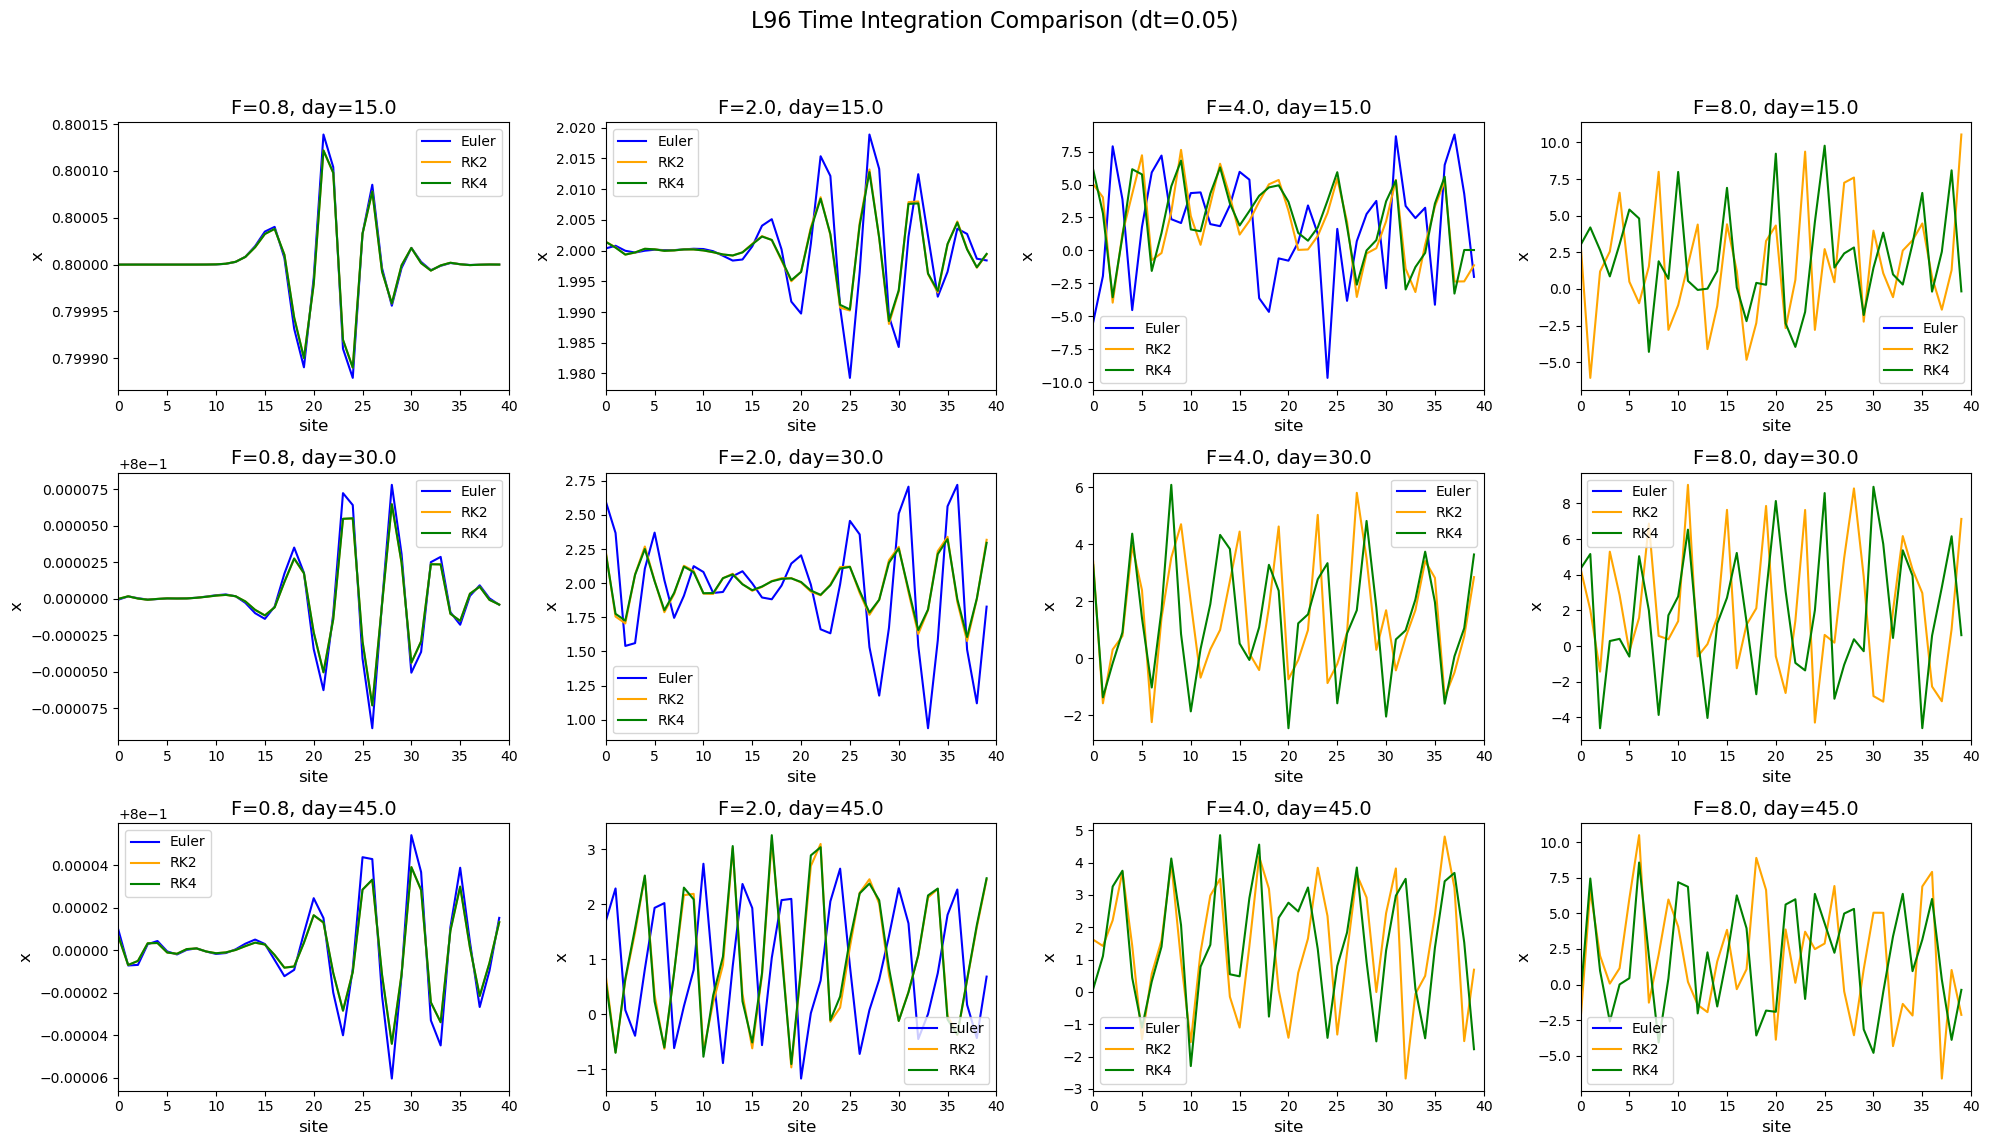

In [4]:
# L96をオイラー法、2次のRunge-Kutta法、4次のRunge-Kutta法で実装する
# F=0.8,2,4,8の場合で15ステップ・30ステップ・45ステップ実行して比較する
N = 40  # 状態変数の数
dt = 0.050  # ステップ幅
F_values = [0.8, 2.0, 4.0, 8.0]  # 比較するF値
steps = 400  # シミュレーションのステップ数
days_list = [15.0, 30.0, 45.0]  # 比較する経過日数 (ステップ幅0.05としたとき、1が5日に対応する→0.2が1日対応→dt=0.5のとき、1ステップ0.25日相当)
methods = ['euler', 'rk2', 'rk4']  # 比較するメソッド
# 縦F、横ステップの要素数
fig, axes = plt.subplots(len(days_list), len(F_values), figsize=(20, 4*len(days_list)))
# 各F、各ステップ数、各メソッドでシミュレーションを実行
for f_idx, F in enumerate(F_values):
    state_euler = StateArray(N, F, dt, method='euler')
    state_rk2 = StateArray(N, F, dt, method='rk2')
    state_rk4 = StateArray(N, F, dt, method='rk4')
    for i in range(steps):
        if (i)/4 in days_list:
            ax = axes[days_list.index((i)/4), f_idx]
            ax.set_title('F={}, day={}'.format(F, (i)/4), fontsize=14)
            trajectory_euler = state_euler.x
            trajectory_rk2 = state_rk2.x
            trajectory_rk4 = state_rk4.x
            ax.plot(trajectory_euler, label='Euler', color='blue')
            ax.plot(trajectory_rk2, label='RK2', color='orange')
            ax.plot(trajectory_rk4, label='RK4', color='green')
            ax.legend()
            ax.set_xlabel('site', fontsize=12)
            ax.set_ylabel('x', fontsize=12)
            ax.set_xlim(0, N)
        state_euler.step()
        state_rk2.step()
        state_rk4.step()
plt.suptitle('L96 Time Integration Comparison (dt={})'.format(dt), fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()